In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRFRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [3]:
data=pd.read_excel('crop yield data sheet.xlsx')
data

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0
...,...,...,...,...,...,...,...
104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      100 non-null    object 
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(6), object(1)
memory usage: 6.1+ KB


In [5]:
data['Temperatue'].dtype

dtype('O')

In [6]:
data['Temperatue'] = pd.to_numeric(data['Temperatue'], errors='coerce')


In [7]:
data.describe()

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,849.797980,67.808081,32.393939,70.737374,21.131313,18.060606,9.050505
std,400.042676,10.028202,5.426350,6.677079,1.951695,1.817254,1.965902
min,400.000000,50.000000,24.000000,59.000000,18.000000,15.000000,5.500000
25%,450.000000,60.000000,28.000000,65.000000,19.500000,16.000000,7.000000
50%,1150.000000,70.000000,29.000000,71.000000,21.000000,19.000000,9.000000
75%,1237.500000,77.000000,38.000000,77.000000,23.000000,19.000000,11.000000
max,1300.000000,80.000000,40.000000,80.000000,25.000000,22.000000,12.000000


In [8]:
(data.isnull().sum() / len(data)) * 100

,0
Rain Fall (mm),9.174312
Fertilizer,9.174312
Temperatue,9.174312
Nitrogen (N),9.174312
Phosphorus (P),9.174312
Potassium (K),9.174312
Yeild (Q/acre),9.174312


In [9]:
data.shape

(109, 7)

In [10]:
data.duplicated().sum()

np.int64(13)

In [11]:
data.drop_duplicates(inplace=True)

In [12]:
corr=data.corr(numeric_only=True)
corr

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
Rain Fall (mm),1.000000,0.885400,-0.967736,0.871885,0.772468,0.804093,0.882383
Fertilizer,0.885400,1.000000,-0.863135,0.904937,0.816096,0.751365,0.824444
Temperatue,-0.967736,-0.863135,1.000000,-0.848320,-0.776384,-0.775561,-0.893005
Nitrogen (N),0.871885,0.904937,-0.848320,1.000000,0.779447,0.800065,0.872730
Phosphorus (P),0.772468,0.816096,-0.776384,0.779447,1.000000,0.747676,0.792070
Potassium (K),0.804093,0.751365,-0.775561,0.800065,0.747676,1.000000,0.851340
Yeild (Q/acre),0.882383,0.824444,-0.893005,0.872730,0.792070,0.851340,1.000000


<Axes: >

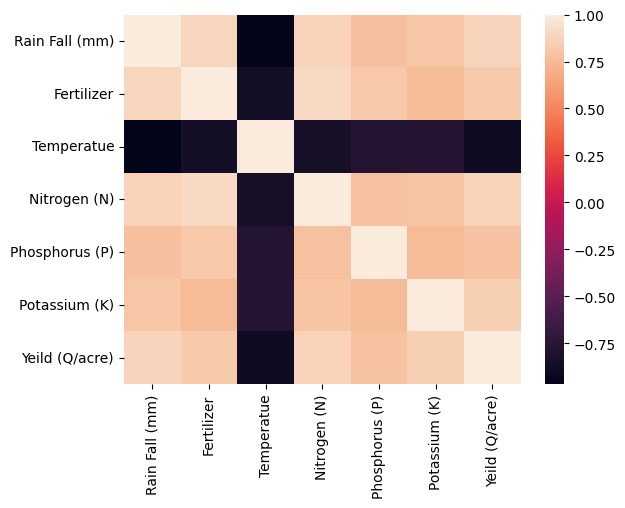

In [13]:
sns.heatmap(corr)

In [14]:
data.columns

Index(['Rain Fall (mm)', 'Fertilizer', 'Temperatue', 'Nitrogen (N)',
       'Phosphorus (P)', 'Potassium (K)', 'Yeild (Q/acre)'],
      dtype='object')

<Axes: xlabel='Rain Fall (mm)', ylabel='Density'>

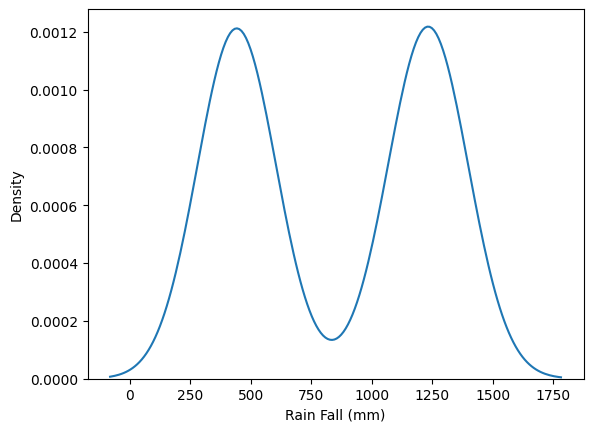

In [15]:
sns.kdeplot(data['Rain Fall (mm)'])

<Axes: xlabel='Fertilizer', ylabel='Density'>

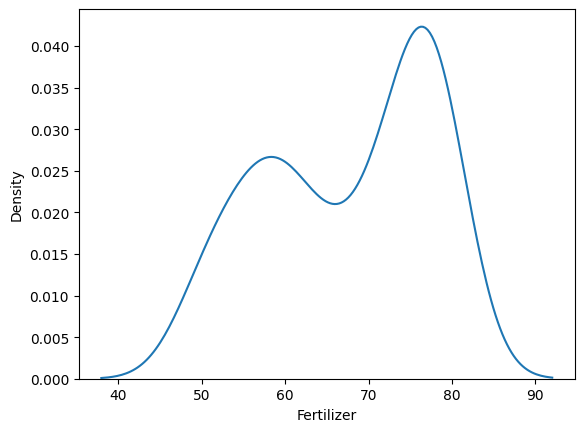

In [16]:
sns.kdeplot(data['Fertilizer'])

<Axes: xlabel='Nitrogen (N)', ylabel='Density'>

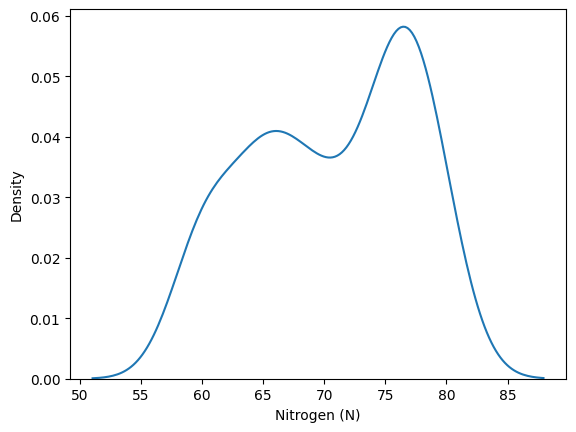

In [17]:
sns.kdeplot(data['Nitrogen (N)'])

<Axes: xlabel='Phosphorus (P)', ylabel='Density'>

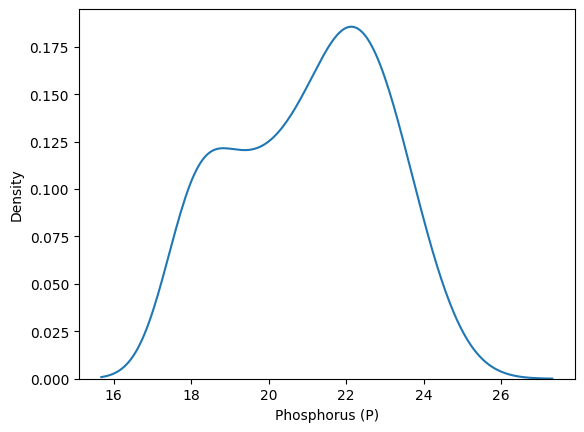

In [18]:
sns.kdeplot(data['Phosphorus (P)'])

<Axes: xlabel='Potassium (K)', ylabel='Density'>

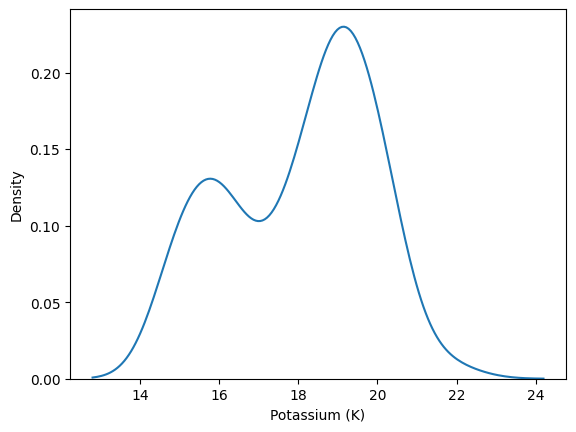

In [19]:
sns.kdeplot(data['Potassium (K)'])

<Axes: xlabel='Temperatue', ylabel='Density'>

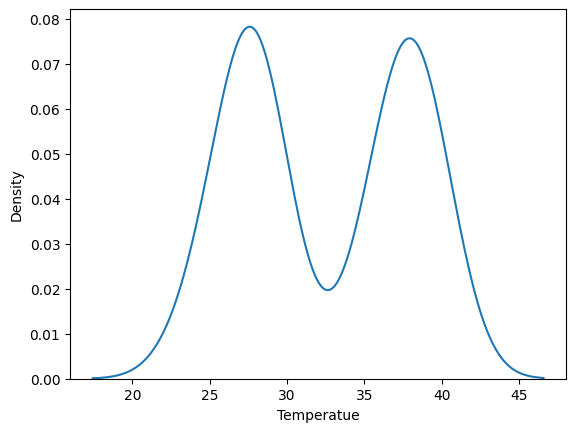

In [20]:
sns.kdeplot(data['Temperatue'])

In [21]:
num=data.columns

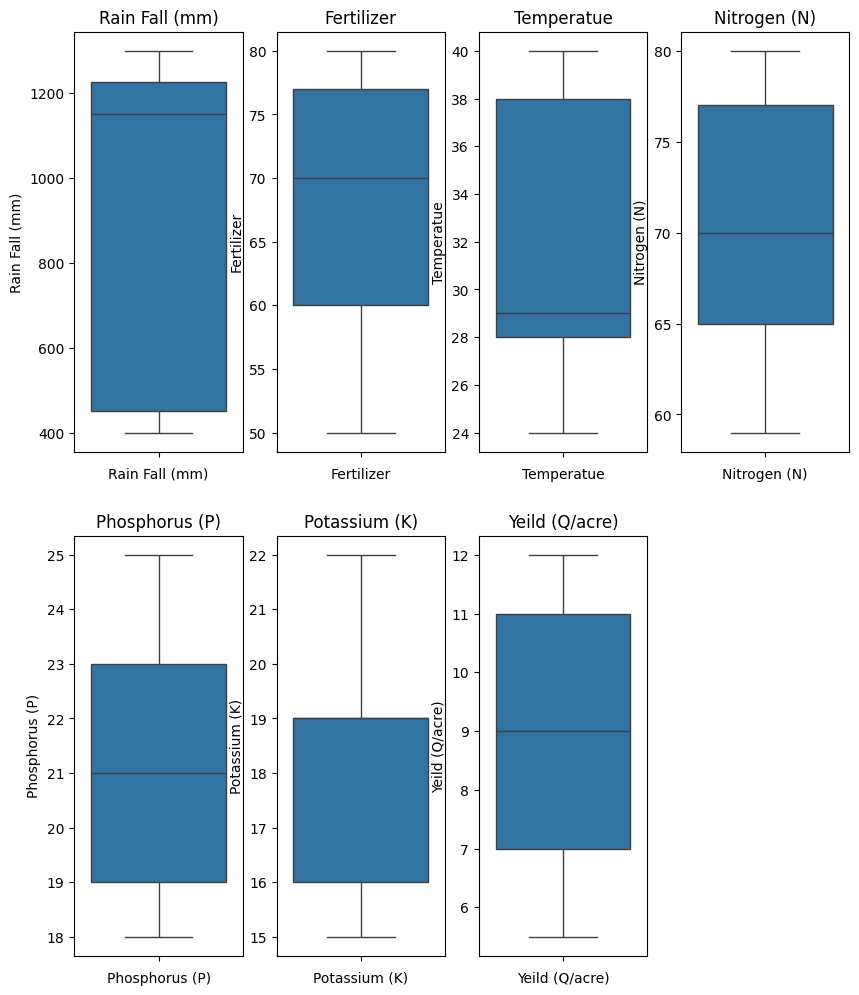

In [22]:
plt.figure(figsize=(10,12))
num = data.select_dtypes(include=np.number).columns
for index,col in enumerate(num):
  plt.subplot(2,4,index+1)
  sns.boxplot(data[col])
  plt.title(col)
  plt.xlabel(col)

plt.show()

In [23]:
data.columns

Index(['Rain Fall (mm)', 'Fertilizer', 'Temperatue', 'Nitrogen (N)',
       'Phosphorus (P)', 'Potassium (K)', 'Yeild (Q/acre)'],
      dtype='object')

In [59]:
for i in data.columns:
  print(" ")
  print(f' skewness for {i} :',data[i].skew())

 
 skewness for Rain Fall (mm) : -0.013011975961075688
 
 skewness for Fertilizer : -0.361609043335328
 
 skewness for Temperatue : 0.005246150054674629
 
 skewness for Nitrogen (N) : -0.26530479503169996
 
 skewness for Phosphorus (P) : -0.1709034282992217
 
 skewness for Potassium (K) : -0.32962748559050925
 
 skewness for Yeild (Q/acre) : -0.12903396898280825


In [24]:
num=['Rain Fall (mm)', 'Fertilizer', 'Temperatue', 'Nitrogen (N)',
       'Phosphorus (P)', 'Potassium (K)']

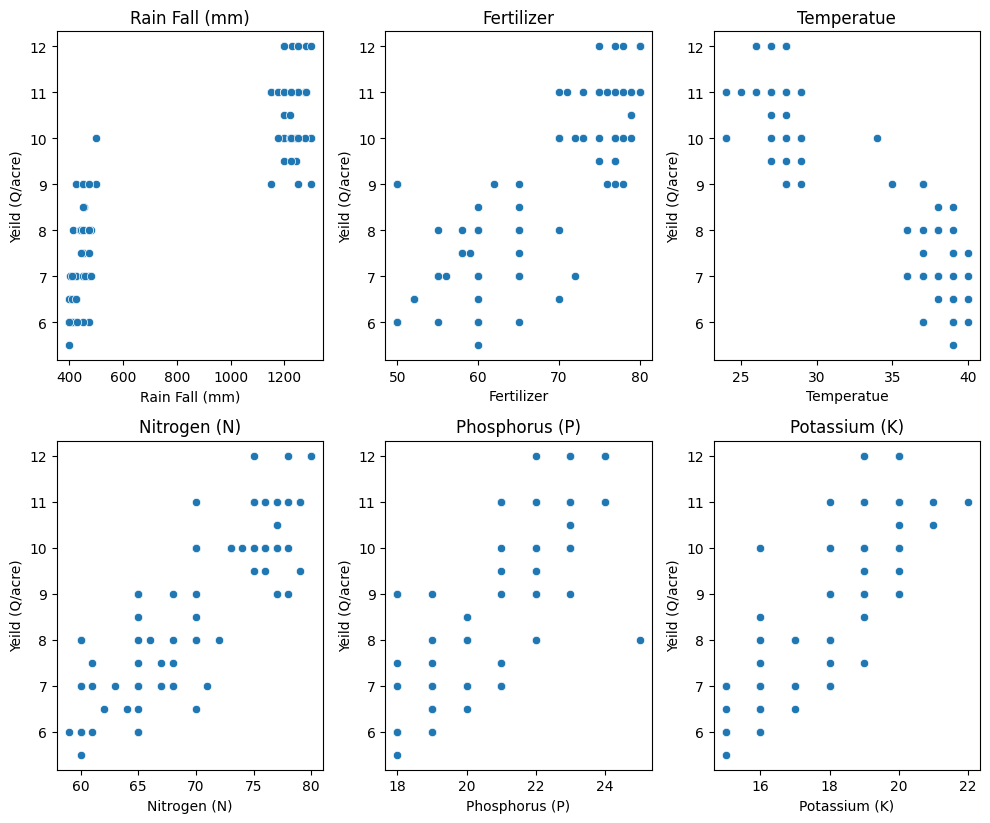

In [25]:
plt.figure(figsize=(10,12))

for index,col in enumerate(num):
  plt.subplot(3,3,index+1)
  sns.scatterplot(x=data[col],y=data['Yeild (Q/acre)'])
  plt.title(col)
  plt.xlabel(col)
  plt.tight_layout()

plt.show()

In [26]:
x=data.drop(columns=['Yeild (Q/acre)'])

In [27]:
y=data['Yeild (Q/acre)']

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [29]:
input=['Rain Fall (mm)', 'Fertilizer', 'Temperatue', 'Nitrogen (N)',
       'Phosphorus (P)', 'Potassium (K)']

In [30]:
median_value = data['Yeild (Q/acre)'].median()
data['Yeild (Q/acre)'] = data['Yeild (Q/acre)'].fillna(median_value)


In [31]:
col=ColumnTransformer([
    ('impute',SimpleImputer(strategy='median'),input),
    ('scale',StandardScaler(),input)
],remainder='passthrough'
)

In [32]:
pipe1=Pipeline([
    ('trf',col),
    ('lr',LinearRegression())
])

In [33]:
data.columns

Index(['Rain Fall (mm)', 'Fertilizer', 'Temperatue', 'Nitrogen (N)',
       'Phosphorus (P)', 'Potassium (K)', 'Yeild (Q/acre)'],
      dtype='object')

In [34]:
trf1=ColumnTransformer(
    [
    ('imputer', SimpleImputer(strategy='median'),[['Rain Fall (mm)', 'Fertilizer', 'Temperatue', 'Nitrogen (N)',
       'Phosphorus (P)', 'Potassium (K)']]),

    ],remainder='passthrough'
)

In [35]:
trf2=ColumnTransformer([
    ('scaler', StandardScaler(),[['Rain Fall (mm)', 'Fertilizer', 'Temperatue', 'Nitrogen (N)',
       'Phosphorus (P)', 'Potassium (K)']])
])

In [36]:
pipe2=Pipeline(
    [
        ('trf1',trf1),
        ('trf2',trf2),
        ('lr',LinearRegression())
    ]
)

In [37]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

col = ColumnTransformer(
    [
        ('num', numerical_transformer, input)
    ],
    remainder='passthrough'
)

pipe1 = Pipeline([
    ('trf', col),
    ('lr', LinearRegression())
])

# Ensure y_train and y_test do not contain NaNs
y_train = y_train.fillna(median_value)
y_test = y_test.fillna(median_value)

pipe1.fit(x_train, y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Rain Fall (mm)',
                                                   'Fertilizer', 'Temperatue',
                                                   'Nitrogen (N)',
                                                   'Phosphorus (P)',
                                                   'Potassium (K)'])])),
                ('lr', LinearRegression())])

In [38]:
y_pred=pipe1.predict(x_test)

In [39]:
r2_score(y_test,y_pred)

0.9367055975513017

In [40]:
pipe2=Pipeline(
    [
         ('trf', col),
    ('dt', DecisionTreeRegressor())
    ]
)

In [41]:
pipe2.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Rain Fall (mm)',
                                                   'Fertilizer', 'Temperatue',
                                                   'Nitrogen (N)',
                                                   'Phosphorus (P)',
                                                   'Potassium (K)'])])),
                ('dt', DecisionTreeRegressor())])

In [42]:
y_pred=pipe2.predict(x_test)

In [43]:
r2_score(y_test,y_pred)

0.8360655737704917

In [44]:
pipe3=Pipeline(
    [
         ('trf', col),
    ('xg',XGBRFRegressor() )
    ]
)

In [45]:
pipe3.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Rain Fall (mm)',
                                                   'Fertilizer', 'Temperatue',
                                                   'Nitrogen (N)',
                                                   'Phosphorus (P)',
                                                   'Potassium (K)'])])),
                ('xg',
                 XGBRFRegressor(base_score=None, booster=None, callbacks=None,
                                colsample_byleve...
                                gamma=None, grow_policy=None,
                                importance_type=None,
                                interaction_constraints=None, max_bin=None,
                                max_cat_threshold=None, max_cat_to_onehot=None,
                                max_delta_step=None, max_depth=None,
                                max_leaves=None, min_child_weight=None,
                                missing=nan, monotone_constraints=None,
                                multi_strategy=None, n_estimators=None,
                                n_jobs=None, num_parallel_tree=None,
                                objective='reg:squarederror', random_state=None, ...))])

In [46]:
y_pred=pipe3.predict(x_test)

In [47]:
r2_score(y_test,y_pred)

0.9012116059551157

In [48]:
pipe4=Pipeline(
    [
         ('trf', col),
    ('rf',RandomForestRegressor() )
    ]
)

In [49]:
pipe4.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Rain Fall (mm)',
                                                   'Fertilizer', 'Temperatue',
                                                   'Nitrogen (N)',
                                                   'Phosphorus (P)',
                                                   'Potassium (K)'])])),
                ('rf', RandomForestRegressor())])

In [50]:
y_pred=pipe4.predict(x_test)

In [51]:
r2_score(y_test,y_pred)

0.9085616167326173

In [52]:
pipe5=Pipeline(
    [
         ('trf', col),
    ('gb',GradientBoostingRegressor())
    ]
)

In [53]:
pipe5.fit(x_train,y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Rain Fall (mm)',
                                                   'Fertilizer', 'Temperatue',
                                                   'Nitrogen (N)',
                                                   'Phosphorus (P)',
                                                   'Potassium (K)'])])),
                ('gb', GradientBoostingRegressor())])

In [54]:
y_pred=pipe5.predict(x_test)

In [55]:
r2_score(y_test,y_pred)

0.9132753657211894

# Linear Regression has best performance with r2_score of 93